# Calculate coupling efficiency of misaligned extended source in the presence of jitter

In [2]:
import sys
from pathlib import Path

src_path = Path("/Users/tliu/oh_suppression/codes/src")

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from oh_suppression.coupling import *

In [3]:
from oh_suppression.point_source_coupling import *
from oh_suppression.coupling_vs_radius_sweeps import *
from oh_suppression.extended_source_coupling import *

In [4]:
import astropy.units as u
from astropy.modeling.models import Sersic2D
# Source: https://docs.astropy.org/en/stable/api/astropy.modeling.functional_models.Sersic2D.html

In [5]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import special #import jv, kv
# from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [6]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [7]:
from scipy.optimize import brentq
from scipy.optimize import fminbound

In [8]:
from dataclasses import dataclass
import pandas as pd

In [9]:
from joblib import Parallel, delayed
import os

In [10]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 
# fibre core radius
a = 5e-6 
# numerical aperture of fibre
NA = 0.1 

# Calculate the normalised frequency (V-number) of the fibre
V = 2 * pi * (a / lam0) * NA
print(f"V-number of the fibre: {V:.2f}")

V-number of the fibre: 2.09


In [11]:
V_max_single = 2.405 # The cutoff V-number for single-mode operation in a step-index fibre
a_max_single = V_max_single * lam0 / (2 * np.pi * NA)
print(f"Maximum core radius for single-mode operation: {a_max_single*1e6:.20f} microns")

Maximum core radius for single-mode operation: 5.74151457204012416469 microns


In [12]:
NA = 0.1
F_fibre = 1 / (2 * np.tan(np.arcsin(NA)))
Magnification = F_fibre / 49.9
F_focus = 49.9
D_M1 = 8.0
D_M1 = 8.0 # Diameter of the primary mirror in meters
D_obstruction = 1.0 # Diameter of the central obstruction in meters
alpha_vlt = D_obstruction / D_M1 # Ratio of the central obstruction to the primary mirror diameter
rad_to_arcsec = (180 / np.pi) * 3600
plate_scale_coude = rad_to_arcsec / (F_focus * D_M1)  # arcsec / metre at telescope focal plane
plate_scale_demag = plate_scale_coude / Magnification # arcsec / metre at the demagnified fibre input plane

In [13]:
Magnification

np.float64(0.09969813999064328)

In [14]:
# Focal length of the Coudé focus in meters according to VLT documentation 
f_coude = 399

In [15]:
print(f"Plate scale at the Coudé focus: {plate_scale_coude*1e-3:.2f} arcsec/mm")

Plate scale at the Coudé focus: 0.52 arcsec/mm


In [16]:
n_sersic = 3.335 # sersic index, n>0.36
Re_arcsec = 0.101 # half light radius in arcseconds
q_param = 0.514 # projected axis ratio of the galaxy, b/a, where b is the semi-minor axis and a is the semi-major axis. This is used to calculate the effective radius in the direction of the fibre input plane.
# PA = 0 # assumed to be 0 for simplicity, but can be adjusted based on the orientation of the galaxy in the sky.
PA_deg = -88.7
ellip = 1 - q_param # ellipticity of the galaxy, defined as 1 - (b/a)

In [17]:
# Sersic profile has a scaling constant b_n, for n>0.36, b_n can be approximated as b_n = 2n - 1/3 + 4/(405n) + 46/(25515n^2) + 131/(1148175n^3) 
# - 2194697/(30690717750n^4)
b_n = 2 * n_sersic - 1/3 + 4/(405*n_sersic) + 46/(25515*n_sersic**2) + 131/(1148175*n_sersic**3) - 2194697/(30690717750*n_sersic**4)

In [18]:
# Sersic2D?

In [19]:
# Fibre front grid in metres

r_max = 125e-6 # maximum radius of the CLADDING region to be considered in the 2D grid, in meters
n_grid = 1000 

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [20]:
FOV_test = plate_scale_demag * 2 * r_max
FOV_test_smf = plate_scale_demag * 2 * 5.7e-6
print(f"Test FOV: {FOV_test:.4f} arcsec")
print(f"Test FOV for SMF: {FOV_test_smf:.4f} arcsec")

Test FOV: 1.2956 arcsec
Test FOV for SMF: 0.0591 arcsec


In [21]:
# Angular grid for the Sersic profile, in radians

# angular_extent = 0.5 # arcsec (I should probably find the FOV of a 125e-6m light bucket)
angular_extent = 1.30/2 # arcsec, which is half of the FOV of a 125e-6m light bucket at the Coudé focus, based on the plate scale calculated above.

x_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)
y_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)

x_arcsec, y_arcsec = np.meshgrid(x_arcsec_1d, y_arcsec_1d)

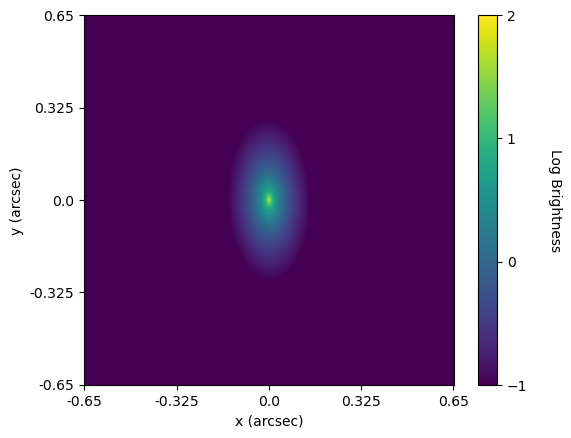

In [22]:
model_cent = Sersic2D(amplitude=1, r_eff = Re_arcsec, n = n_sersic, x_0=0, y_0=0, ellip=ellip, theta=np.radians(PA_deg))

# img is a numpy array of the Sersic profile evaluated at each point in the 2D grid defined by x_arcsec and y_arcsec. 
img = model_cent(x_arcsec, y_arcsec)
log_img = np.log10(img)

fig, ax = plt.subplots()
im = ax.imshow(log_img, origin='lower', interpolation='nearest',
               vmin=-1, vmax=2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Log Brightness', rotation=270, labelpad=25)
# Set ticks in arcseconds for the x and y axes
ax.set_xticks(np.linspace(0, n_grid-1, 5))
ax.set_xticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
ax.set_yticks(np.linspace(0, n_grid-1, 5))
ax.set_yticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
cbar.set_ticks([-1, 0, 1, 2])
plt.xlabel('x (arcsec)')
plt.ylabel('y (arcsec)')
plt.show()

In [23]:
# Only test for a single normalised frequency at r=5.7microns for my first test of decentred position
prepared_smf_mode_5p7micron = prepare_modes_2d(
                                x, y,
                                a=5.7e-6, 
                                NA=NA, 
                                lam0=lam0, 
                                az_sym=True, 
                                mode_case="few_mode"
                            )

In [24]:
decentre_array_cladding = np.linspace(0, r_max, 1000) # array of decentre positions from 0 to r_max, in meters

eta_psf_clad_5p7_decent_array, mode_result_single_5p7_clad = eta_psf_vs_decentre_position_2d(
    prepared_smf_mode_5p7micron,
    x, y, x_1d, y_1d,
    lam0=lam0,
    F_eff=F_fibre,
    alpha=alpha_vlt,
    decentre_array=decentre_array_cladding,
    E_S=1.0,
    direction_angle=0.0
)

In [25]:
# eta_psf_clad_5p7_decent_array

In [64]:
decentre_array_cladding

array([0.00000000e+00, 1.25125125e-07, 2.50250250e-07, 3.75375375e-07,
       5.00500501e-07, 6.25625626e-07, 7.50750751e-07, 8.75875876e-07,
       1.00100100e-06, 1.12612613e-06, 1.25125125e-06, 1.37637638e-06,
       1.50150150e-06, 1.62662663e-06, 1.75175175e-06, 1.87687688e-06,
       2.00200200e-06, 2.12712713e-06, 2.25225225e-06, 2.37737738e-06,
       2.50250250e-06, 2.62762763e-06, 2.75275275e-06, 2.87787788e-06,
       3.00300300e-06, 3.12812813e-06, 3.25325325e-06, 3.37837838e-06,
       3.50350350e-06, 3.62862863e-06, 3.75375375e-06, 3.87887888e-06,
       4.00400400e-06, 4.12912913e-06, 4.25425425e-06, 4.37937938e-06,
       4.50450450e-06, 4.62962963e-06, 4.75475475e-06, 4.87987988e-06,
       5.00500501e-06, 5.13013013e-06, 5.25525526e-06, 5.38038038e-06,
       5.50550551e-06, 5.63063063e-06, 5.75575576e-06, 5.88088088e-06,
       6.00600601e-06, 6.13113113e-06, 6.25625626e-06, 6.38138138e-06,
       6.50650651e-06, 6.63163163e-06, 6.75675676e-06, 6.88188188e-06,
      

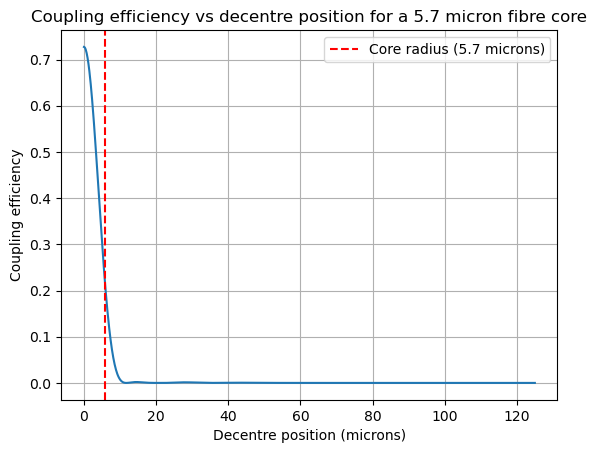

In [26]:
plt.plot(decentre_array_cladding*1e6, eta_psf_clad_5p7_decent_array)
plt.xlabel("Decentre position (microns)")
plt.ylabel("Coupling efficiency")
plt.title("Coupling efficiency vs decentre position for a 5.7 micron fibre core")
plt.axvline(5.7, color='r', linestyle='--', label='Core radius (5.7 microns)')
plt.legend()
plt.grid()

## Method 1: Monte Carlo Averaging

In [27]:
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import PchipInterpolator
from tqdm.auto import tqdm

/Users/tliu/.conda/envs/oh_suppression_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
# np.interp?

### Step 1 - set up Monte Carlo sampling for a perfectly positioned point source

In [29]:
# Create NumPy's random-number generator.
# Setting a seed means that every time this cell is run,
# the same sequence of random numbers will be generated.
# This is useful while testing and debugging the calculation.
rng = np.random.default_rng(seed=49)

# Number of random jitter positions that will be simulated.
# Each sample represents one possible instantaneous position
# of the point-source PSF relative to its nominal position.
n_samples = 300


In [30]:
# Note: RMS can be expressed as σ (sigma), but only if the mean error is exactly zero.

# convert the jitter FWHM to sigma for the Rayleigh distribution
jitter_rms_mas = 20

# Convert jitter from milliarcseconds to radians
sigma_theta_rad = jitter_rms_mas * 1e-3 / 206265

# Convert the jitter from angular units to linear units at the fibre plane
# Standard deviation (RMS) of the assumed jitter at the fibre plane.
sigma_jitter_fibre = Magnification * f_coude * sigma_theta_rad

print(
    f"One-axis RMS jitter at fibre plane: "
    f"{sigma_jitter_fibre * 1e6:.4f} µm"
)


One-axis RMS jitter at fibre plane: 3.8571 µm


### Step 2 - Generate random x- and y-jitter

In [31]:
# rng.normal?

In [32]:
# Draw n_samples of random jitter positions in the x and y direction, for a normal distribution with mean 0 and standard deviation sigma_jitter_fibre.
delta_x = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter x-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one x-displacement for each Monte Carlosample
)

# Assmuming jitter is isotropic, the y-displacements are drawn from the same distribution as the x-displacements.
delta_y = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter y-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one y-displacement for each Monte Carlosample
)

### Step 3 - Convert the 2D displacement into radial displacement

In [33]:
# Calculate the radial distance 
r_samples = np.sqrt(delta_x**2 + delta_y**2)

In [34]:
# For every random radial jitter position r_samples,
# estimate the corresponding point-source coupling efficiency from our previously calculated eta-versus-decentre curve.

# eta_samples = np.interp(
#     r_samples, # Positions where we WANT to know eta.
#     decentre_array_cladding, # Radial positions where eta was actually calculated using the optical overlap integral.
#     eta_psf_clad_5p7_decent_array # Coupling efficiencies calculated at those positions. 
#     )

# Construct a smooth interpolation function from the coupling
# efficiencies that were calculated at each radial decentre.
eta_interp = PchipInterpolator(
    decentre_array_cladding,
    eta_psf_clad_5p7_decent_array,
    extrapolate=False
)

# Evaluate the interpolated coupling efficiency at each
# randomly generated radial jitter displacement.
eta_samples = eta_interp(r_samples)

In [35]:
# Calculate the arithmetic mean of all sampled coupling efficiencies. 
eta_mean_MC = np.mean(eta_samples) 

# Display the resulting estimate of the mean coupling efficiency
# in the presence of jitter.
print(
    f"Mean jittered coupling efficiency = "
    f"{eta_mean_MC:.6f}"
)

Mean jittered coupling efficiency = 0.354868


In [36]:
# Calculate the standard deviation of the individual coupling
# efficiencies sampled during the simulated jitter.
#
# This describes how much the instantaneous coupling varies
# because of the random pointing displacement.
eta_std = np.std(
    eta_samples, # Array of sampled coupling efficiencies.
    ddof=1 # Use the unbiased estimator for the standard deviation, which divides by (N-1) instead of N.
)


# Calculate the standard error of the Monte Carlo mean.
#
# This estimates the statistical uncertainty caused by using
# only a finite number of Monte Carlo samples.
#
# The uncertainty decreases approximately as 1/sqrt(N).
eta_mean_error = eta_std / np.sqrt(n_samples)


print(
    f"Mean coupling = "
    f"{eta_mean_MC:.6f} ± {eta_mean_error:.6f}"
)

Mean coupling = 0.354868 ± 0.012495


## Jitter with both x- and y-direction probability distiributions computed with Monte Carlo Averaging

In [37]:
x

array([[-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       ...,
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ],
       [-0.000125  , -0.00012475, -0.0001245 , ...,  0.0001245 ,
         0.00012475,  0.000125  ]], shape=(1000, 1000))

In [38]:
y

array([[-0.000125  , -0.000125  , -0.000125  , ..., -0.000125  ,
        -0.000125  , -0.000125  ],
       [-0.00012475, -0.00012475, -0.00012475, ..., -0.00012475,
        -0.00012475, -0.00012475],
       [-0.0001245 , -0.0001245 , -0.0001245 , ..., -0.0001245 ,
        -0.0001245 , -0.0001245 ],
       ...,
       [ 0.0001245 ,  0.0001245 ,  0.0001245 , ...,  0.0001245 ,
         0.0001245 ,  0.0001245 ],
       [ 0.00012475,  0.00012475,  0.00012475, ...,  0.00012475,
         0.00012475,  0.00012475],
       [ 0.000125  ,  0.000125  ,  0.000125  , ...,  0.000125  ,
         0.000125  ,  0.000125  ]], shape=(1000, 1000))

In [39]:
img.shape

(1000, 1000)

In [40]:
r_max

0.000125

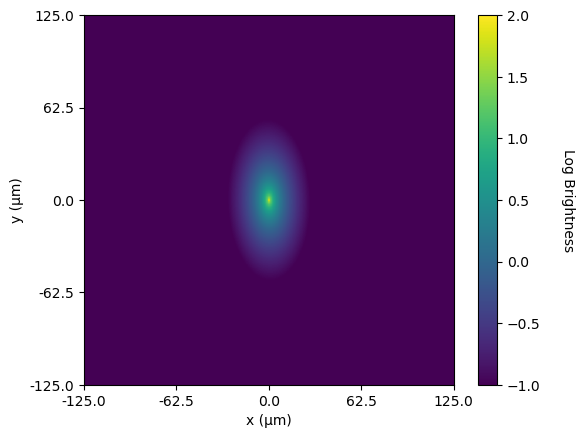

In [41]:
fig, ax = plt.subplots()
im = ax.imshow(
    log_img,
    origin="lower",
    interpolation="nearest",
    extent=[-r_max, r_max, -r_max, r_max],
    vmin=-1,
    vmax=2,
)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Log Brightness", rotation=270, labelpad=25)

ticks = np.linspace(-r_max, r_max, 5)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([f"{v*1e6:.1f}" for v in ticks])
ax.set_yticklabels([f"{v*1e6:.1f}" for v in ticks])

plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()

### Interpolating the point-source coupling efficiency

The point-source coupling efficiency, $\eta_{\mathrm{psf}}$, was previously calculated as a function of the **radial decentre** of a point source from the fibre centre. These calculations were performed only at the discrete radial positions contained in `decentre_array_cladding`, giving the corresponding coupling efficiencies in `eta_psf_clad_5p7_decent_array`.

Therefore, the calculated data provide a discrete representation of the radial coupling response,

$$
r \longrightarrow \eta_{\mathrm{psf}}(r),
$$

where $r$ is the radial separation between a point source and the centre of the fibre.

However, when constructing a two-dimensional coupling map, each position $(x,y)$ on the focal-plane grid has a radial distance from the fibre centre

$$
r(x,y) = \sqrt{x^2+y^2}.
$$

These radial distances will generally not coincide exactly with the discrete values in `decentre_array_cladding`. An interpolation function is therefore required to estimate $\eta_{\mathrm{psf}}(r)$ between the radial positions at which the coupling efficiency was explicitly calculated.

A `PchipInterpolator` is used to construct this continuous numerical representation of $\eta_{\mathrm{psf}}(r)$. PCHIP provides a smooth, shape-preserving interpolation between the calculated values and avoids introducing artificial oscillations between neighbouring samples.

Importantly, `eta_psf_interp` is **not itself a two-dimensional coupling map**. It represents the one-dimensional radial relationship

$$
\eta_{\mathrm{psf}} = \eta_{\mathrm{psf}}(r).
$$

To construct the two-dimensional coupling response of the fibre, the radial distance of every $(x,y)$ grid position from the fibre centre is first calculated. The interpolation function is then evaluated at each of these radial distances:

$$
\eta_{\mathrm{map}}(x,y)
=
\eta_{\mathrm{psf}}\left(\sqrt{x^2+y^2}\right).
$$

For a centred fibre, this produces a fixed, circularly symmetric two-dimensional coupling map centred at $(0,0)$. During the jitter simulation, this fibre coupling response remains fixed while the galaxy surface-brightness distribution is displaced relative to it.

If a static fibre misalignment is introduced later, the same radial coupling function can be retained, but the radial distance is instead measured from the displaced fibre centre.

In [42]:
# To construct the fixed 2D fibre coupling response, eta_psf_interp can then
# be evaluated at the radial distance of every (x, y) point from the fibre
# centre. This replaces the previous np.interp step used to construct
# eta_psf_dr_map_2d.
#
# The same interpolated radial response can also be used for a misaligned
# fibre by calculating r from the displaced fibre centre instead.
eta_psf_interp = PchipInterpolator(
    decentre_array_cladding,          # Radial decentre positions where eta_psf was explicitly calculated.
    eta_psf_clad_5p7_decent_array,    # Point-source coupling efficiency at each radial decentre position.
    extrapolate=False                 # Do not estimate eta_psf outside the calculated radial range.
)

In [43]:
eta_psf_interp

In [44]:
# Calculate original extended source coupling
r_grid = np.sqrt(x**2 + y**2)

# # Point source coupling response at every position across the 2D grid
eta_psf_2d = eta_psf_interp(r_grid)

In [ ]:
# Update: We are no longer using eta_psf_2d, because we are now calculating the coupling efficiency for each jittered 
# position directly for the brightness profile of the extended source instead of shifting the coupling efficiency across the 
# focal plane.
eta_psf_2d

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1000, 1000))

In [46]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=49)

# Number of Monte carlo realisations
n_samples = 300

# print a sentence
print(f"The RMS jitter in fibre plane is, sigma_jitter_fibre: {sigma_jitter_fibre} metres")


The RMS jitter in fibre plane is, sigma_jitter_fibre: 3.857131152281451e-06 metres


In [47]:
# Random x-component of the image displacement

delta_x = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter x-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one x-displacement for each Monte Carlosample
)

# Random y-component of the image displacement
delta_y = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter y-direction
    scale=sigma_jitter_fibre, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one y-displacement for each Monte Carlosample
)


In [48]:
# np.empty?

In [49]:
tqdm?

Init signature: tqdm(iterable=None, *args, **kwargs)
Docstring:      Asynchronous-friendly version of tqdm.
File:           ~/.conda/envs/oh_suppression_env/lib/python3.12/site-packages/tqdm/asyncio.py
Type:           type
Subclasses:     

In [50]:
# eta_extended_source_2d?

In [51]:
decentre_array_cladding.shape

(1000,)

In [52]:
def sigma_jitter_milliarcsec_to_metres(sigma_jitter_rms, focal_length, demagnification): 
    """
    Convert the RMS jitter from milliarcseconds to metres at the fibre plane.

    Parameters: 
    sigma_jitter_rms : float
        RMS jitter in milliarcseconds.
    focal_length : float
        Focal length of the telescope in metres.
    demagnification : float 
        Demagnification factor from the telescope focal plane to the fibre plane, done by the reimaging optics. 

    Returns:
    float
        RMS jitter in metres at the fibre plane.
    """
    # Convert jitter from milliarcseconds to radians
    sigma_theta_radians = sigma_jitter_rms * 1e-3 / 206265 

    # Convert jitter from radians to physical units (metres) at the fibre plane using the focal length and demagnification

    sigma_jitter_metres = demagnification * focal_length * sigma_theta_radians

    return sigma_jitter_metres

In [ ]:
# Fixed fibre coupling map

# R is the radial distance from the fibre centre for every point in the 2D grid defined by x and y.
R = np.sqrt(x**2 + y**2)

# Create an empty 2D array to fix the fibre coupling response across the 2D grid so the eta_map of the fibre inherently 
# never changes for our perfectly aligned fibre, and the only change in the coupling efficiency is due to the jittered galaxy image. 
eta_map_fixed = np.zeros_like(R)

# Determine which points in the 2D grid are within the range of the decentre_array_cladding, so that we can evaluate 
# eta_psf_interp at those points.
inside_range = (
    R <= decentre_array_cladding[-1]
)

# Interpolate the point-source coupling response at every point in the 2D grid that is within the range of 
# the decentre_array_cladding, and assign those values to the corresponding points in eta_map_fixed.
eta_map_fixed[inside_range] = eta_psf_interp(
    R[inside_range]
)

In [63]:
range(n_samples)

range(0, 300)

In [ ]:
# Monte Carlo Averaging, where n_samples is the number of random jitter positions that will be simulated. 
# Each sample represents one possible instantaneous position of the point-source PSF relative to its nominal position.
eta_samples_20mas = np.empty(n_samples)

# Write a loop to iterate over each of the n_samples random jitter positions, and for each position, calculate the correponding
# coupling efficiency of the displaced galaxy image relative to the fixed fibre, and store that value in eta_samples_20mas. 
for i in range(n_samples):

    # Convert the random position displacement due to jitter from metres to arcseconds, for x and y directions, 
    # using the plate scale at the demagnified fibre input plane.
    dx_arcsec = delta_x[i] * plate_scale_demag 
    dy_arcsec = delta_y[i] * plate_scale_demag

    # Shift the galaxy brightness distribution relative to the fixed fibre, and create a new brightness distribution using 
    # the Sersic2D model model_cent, evaluated at the jittered positions in arcseconds.
    img_jittered = model_cent(
        x_arcsec - dx_arcsec,
        y_arcsec - dy_arcsec
    )

    # Calculate the coupling efficiency of the displaced galaxy
    eta_samples_20mas[i] = eta_extended_source_2d(
        eta_map_2d=eta_map_fixed,
        galaxy_brightness_2d=img_jittered,
        x_1d=x_1d,
        y_1d=y_1d
    )

In [60]:
# Calculate the mean and standard deviation of the coupling efficiencies
eta_mean_jitter_20mas = np.mean(eta_samples_20mas)
eta_std_jitter_20mas = np.std(eta_samples_20mas, ddof=1)

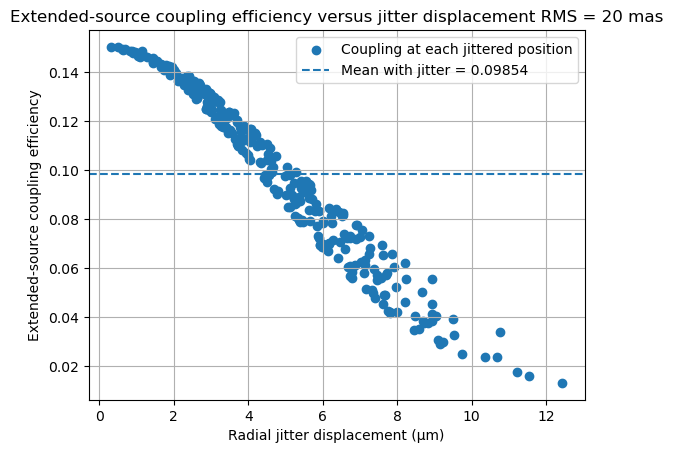

In [61]:
# Calculate the magnitude of each jitter displacement
jitter_displacement = np.sqrt(
    delta_x**2 + delta_y**2
)

plt.figure()

plt.scatter(
    jitter_displacement * 1e6,
    eta_samples_20mas,
    label="Coupling at each jittered position"
)

plt.axhline(
    eta_mean_jitter_20mas,
    linestyle="--",
    label=f"Mean with jitter = {eta_mean_jitter_20mas:.5f}"
)

plt.xlabel("Radial jitter displacement (µm)")

plt.ylabel("Extended-source coupling efficiency")

plt.title("Extended-source coupling efficiency versus jitter displacement RMS = 20 mas")

plt.grid()

plt.legend()

plt.show()

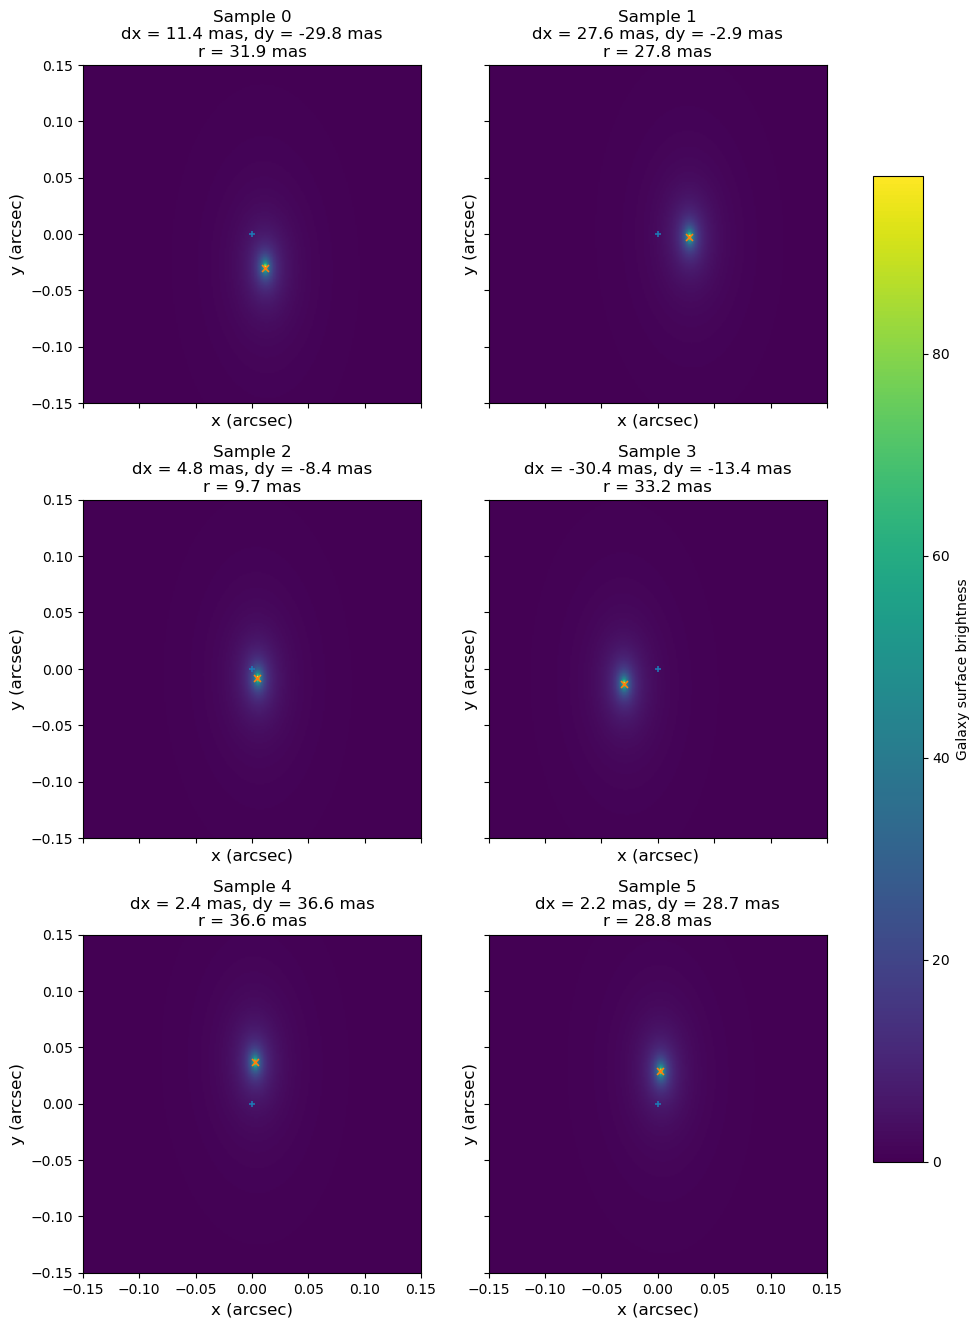

In [56]:
# Select 6 Monte Carlo jitter positions to visualise
sample_indices = [0, 1, 2, 3, 4, 5]

# Create 3 rows and 2 columns
fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 16),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, i in zip(axes, sample_indices):

    # Convert the random jitter displacement from metres on the
    # fibre plane to arcseconds on the galaxy angular grid
    dx_arcsec = delta_x[i] * plate_scale_demag
    dy_arcsec = delta_y[i] * plate_scale_demag

    # Shift the galaxy brightness profile relative to the fixed fibre
    img_jittered = model_cent(
        x_arcsec - dx_arcsec,
        y_arcsec - dy_arcsec
    )

    # Plot the jittered galaxy brightness profile
    image = ax.imshow(
        img_jittered,
        origin="lower",
        extent=[
            x_arcsec_1d[0],
            x_arcsec_1d[-1],
            y_arcsec_1d[0],
            y_arcsec_1d[-1]
        ],
        vmin=0,
        vmax=np.max(img)
    )

    # Mark the fixed fibre centre
    ax.scatter(
        0,
        0,
        marker="+",
        s=25,
        linewidths=1.2,
        label="Fibre centre"
    )

    # Mark the jittered galaxy centre
    ax.scatter(
        dx_arcsec,
        dy_arcsec,
        marker="x",
        s=25,
        linewidths=1.2,
        label="Galaxy centre"
    )

    # Total radial jitter displacement
    r_offset_arcsec = np.sqrt(
        dx_arcsec**2
        + dy_arcsec**2
    )

    ax.set_title(
        f"Sample {i}\n"
        f"dx = {dx_arcsec*1000:.1f} mas, "
        f"dy = {dy_arcsec*1000:.1f} mas\n"
        f"r = {r_offset_arcsec*1000:.1f} mas",
        fontsize=12
    )

    # Zoom in around the fibre
    ax.set_xlim(-0.15, 0.15)
    ax.set_ylim(-0.15, 0.15)

    ax.set_xlabel("x (arcsec)", fontsize=12)
    ax.set_ylabel("y (arcsec)", fontsize=12)

# One colour bar shared by all six panels
fig.colorbar(
    image,
    ax=axes,
    label="Galaxy surface brightness",
    shrink=0.8
)

plt.show()

# Jitter RMS=10 mas

In [65]:
eta_samples_10mas = np.empty(n_samples)

# Repeat experiment for RMS jitter of 10 mas

sigma_metre_10mas = sigma_jitter_milliarcsec_to_metres(10, f_coude, Magnification)
print(f"10 mas RMS jitter corresponds to {sigma_metre_10mas*1e6:.4f} µm at the fibre plane.")

eta_samples_10mas = np.empty(n_samples)


# Random x-component of the image displacement
delta_x_10mas = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter x-direction
    scale=sigma_metre_10mas, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one x-displacement for each Monte Carlosample
)

# Random y-component of the image displacement
delta_y_10mas = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter y-direction
    scale=sigma_metre_10mas, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one y-displacement for each Monte Carlosample
)

# This loop iterates over each Monte Carlo sample, applying a random jitter displacement to the extended source 
# image and calculating the resulting coupling efficiency.

for i in tqdm( 
    range(n_samples), # Iterate over the number of samples
    desc="Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging", # Description for the progress bar
): 

    # Convert the random position displacement due to jitter from metres to arcseconds, for x and y directions,
    # using the plate scale at the demagnified fibre input plane.
    dx_arcsec = delta_x_10mas[i] * plate_scale_demag
    dy_arcsec = delta_y_10mas[i] * plate_scale_demag

    # Create a new brightness distribution for the extended source by evaluating the Sersic2D model at the jittered positions in arcseconds.
    img_jittered_10mas = model_cent(
        x_arcsec - dx_arcsec,
        y_arcsec - dy_arcsec
    )
    
    # Calculate the coupling efficiency
    eta_samples_10mas[i] = eta_extended_source_2d(
        eta_map_2d=eta_map_fixed, # 2D array of point source coupling efficiencies for this jittered position
        galaxy_brightness_2d=img_jittered_10mas, # 2D array of the extended source brightness distribution
        x_1d=x_1d, # 1D array of x-coordinates corresponding to the 2D grid
        y_1d=y_1d, # 1D array of y-coordinates
    )



10 mas RMS jitter corresponds to 1.9286 µm at the fibre plane.


Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging: 100%|██████████| 300/300 [00:06<00:00, 43.04it/s]


In [66]:
# Mean coupling efficiency over all jitter realizations
eta_mean_jitter_10mas = np.mean(eta_samples_10mas)

# Standard deviation of the instantaneous coupling efficiencies
eta_std_jitter_10mas = np.std(
    eta_samples_10mas,
    ddof=1
)

# Monte Carlo uncertainty on the estimated mean
eta_mean_error_10mas = (
    eta_std_jitter_10mas
    / np.sqrt(n_samples)
)

print(
    f"Mean jittered extended-source coupling efficiency = "
    f"{eta_mean_jitter_10mas:.6f}"
)

print(
    f"Standard deviation = "
    f"{eta_std_jitter_10mas:.6f}"
)

print(
    f"Monte Carlo error on mean = "
    f"{eta_mean_error_10mas:.6f}"
)

Mean jittered extended-source coupling efficiency = 0.132000
Standard deviation = 0.015737
Monte Carlo error on mean = 0.000909


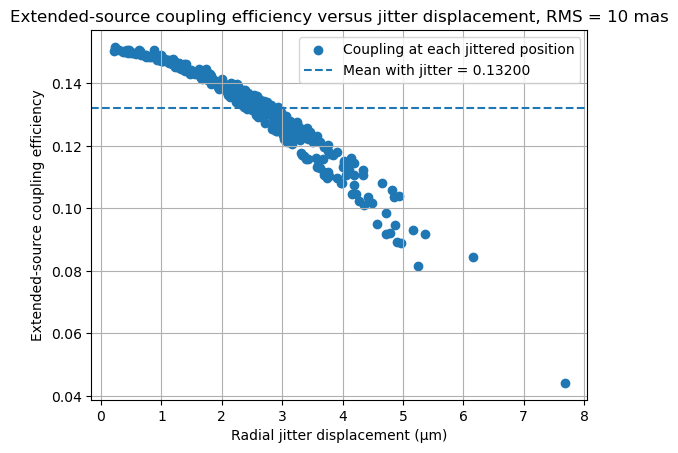

In [67]:
# Calculate the magnitude of each 10 mas jitter displacement
jitter_displacement_10mas = np.sqrt(
    delta_x_10mas**2 + delta_y_10mas**2
)

plt.figure()

plt.scatter(
    jitter_displacement_10mas * 1e6,
    eta_samples_10mas,
    label="Coupling at each jittered position"
)

plt.axhline(
    eta_mean_jitter_10mas,
    linestyle="--",
    label=f"Mean with jitter = {eta_mean_jitter_10mas:.5f}"
)

plt.xlabel("Radial jitter displacement (µm)")

plt.ylabel("Extended-source coupling efficiency")

plt.title(
    "Extended-source coupling efficiency versus jitter displacement, RMS = 10 mas"
)

plt.grid()

plt.legend()

plt.show()

#### Jitter RMS=0 mas

In [69]:
sigma_rms_0mas = 1e-12  # effectively zero jitter for the 0 mas case
sigma_metre_0mas = sigma_jitter_milliarcsec_to_metres(sigma_rms_0mas, f_coude, Magnification) 

In [70]:
eta_samples_0mas = np.empty(n_samples)

# Random x-component of the image displacement
delta_x_0mas = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter x-direction
    scale=sigma_metre_0mas, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one x-displacement for each Monte Carlosample
)

# Random y-component of the image displacement
delta_y_0mas = rng.normal(
    loc=0, # Gaussian centred at 0, no bias in the jitter y-direction
    scale=sigma_metre_0mas, # sets the std or RMS width of the Gaussian distribution
    size=n_samples # Generate one y-displacement for each Monte Carlosample
)

# This loop iterates over each Monte Carlo sample, applying a random jitter displacement to the extended source 
# image and calculating the resulting coupling efficiency.

for i in tqdm( 
    range(n_samples), # Iterate over the number of samples
    desc="Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging", # Description for the progress bar
): 

    # Convert the random position displacement due to jitter from metres to arcseconds, for x and y directions,
    # using the plate scale at the demagnified fibre input plane.
    dx_arcsec = delta_x_0mas[i] * plate_scale_demag
    dy_arcsec = delta_y_0mas[i] * plate_scale_demag

    # Create a new brightness distribution for the extended source by evaluating the Sersic2D model at the jittered positions in arcseconds.
    img_jittered_0mas = model_cent(
        x_arcsec - dx_arcsec,
        y_arcsec - dy_arcsec
    )
    
    # Calculate the coupling efficiency
    eta_samples_0mas[i] = eta_extended_source_2d(
        eta_map_2d=eta_map_fixed, # 2D array of point source coupling efficiencies for this jittered position
        galaxy_brightness_2d=img_jittered_0mas, # 2D array of the extended source brightness distribution
        x_1d=x_1d, # 1D array of x-coordinates corresponding to the 2D grid
        y_1d=y_1d, # 1D array of y-coordinates
    )



Calculating coupling efficiencies for jittered positions using Monte Carlo Averaging: 100%|██████████| 300/300 [00:07<00:00, 41.19it/s]


In [71]:
# Mean coupling efficiency over all jitter realizations
eta_mean_jitter_0mas = np.mean(eta_samples_0mas)

# Standard deviation of the instantaneous coupling efficiencies
eta_std_jitter_0mas = np.std(
    eta_samples_0mas,
    ddof=1
)

# Monte Carlo uncertainty on the estimated mean
eta_mean_error_0mas = (
    eta_std_jitter_0mas
    / np.sqrt(n_samples)
)

print(
    f"Mean jittered extended-source coupling efficiency = "
    f"{eta_mean_jitter_0mas:.6f}"
)

print(
    f"Standard deviation = "
    f"{eta_std_jitter_0mas:.6f}"
)

print(
    f"Monte Carlo error on mean = "
    f"{eta_mean_error_0mas:.6f}"
)

Mean jittered extended-source coupling efficiency = 0.150502
Standard deviation = 0.000000
Monte Carlo error on mean = 0.000000


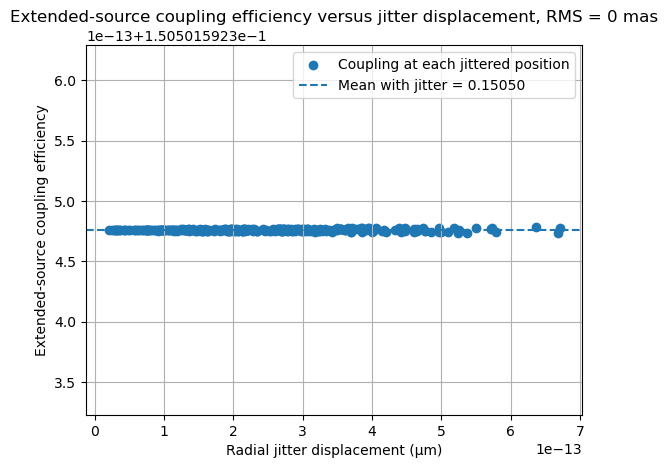

In [72]:
# Calculate the magnitude of each 0 mas jitter displacement
jitter_displacement_0mas = np.sqrt(
    delta_x_0mas**2 + delta_y_0mas**2
)

plt.figure()

plt.scatter(
    jitter_displacement_0mas * 1e6,
    eta_samples_0mas,
    label="Coupling at each jittered position"
)

plt.axhline(
    eta_mean_jitter_0mas,
    linestyle="--",
    label=f"Mean with jitter = {eta_mean_jitter_0mas:.5f}"
)

plt.xlabel("Radial jitter displacement (µm)")

plt.ylabel("Extended-source coupling efficiency")

plt.title(
    "Extended-source coupling efficiency versus jitter displacement, RMS = 0 mas"
)

plt.grid()

plt.legend()

plt.show()

In [73]:
rng.normal?

Signature: rng.normal(loc=0.0, scale=1.0, size=None)
Docstring:
normal(loc=0.0, scale=1.0, size=None)

Draw random samples from a normal (Gaussian) distribution.

The probability density function of the normal distribution, first
derived by De Moivre and 200 years later by both Gauss and Laplace
independently [2]_, is often called the bell curve because of
its characteristic shape (see the example below).

The normal distributions occurs often in nature.  For example, it
describes the commonly occurring distribution of samples influenced
by a large number of tiny, random disturbances, each with its own
unique distribution [2]_.

Parameters
----------
loc : float or array_like of floats
    Mean ("centre") of the distribution.
scale : float or array_like of floats
    Standard deviation (spread or "width") of the distribution. Must be
    non-negative.
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are 

In [206]:
eta_extended_source_2d?

Signature: eta_extended_source_2d(eta_map_2d, galaxy_brightness_2d, x_1d, y_1d)
Docstring:
Calculate the coupling efficiency of an incoherent extended source
into a fibre.

Parameters
----------
eta_map_2d : 2D array
    Point-source coupling efficiency evaluated across the x-y grid.

galaxy_brightness_2d : 2D array
    Linear galaxy brightness distribution evaluated on the same grid.

x_1d, y_1d : 1D arrays
    Coordinates of the x and y grid axes.

Returns
-------
eta_extended : float
    Brightness-weighted coupling efficiency of the extended source.
File:      ~/oh_suppression/codes/src/oh_suppression/extended_source_coupling.py
Type:      function

In [ ]:
# def Monte_Carlo_extended_source_coupling(
#     x, y, 
#     n_samples: int,
#     sigma_jitter_rms_mas: float,
#     focal_length: float,
#     demagnification: float,
#     decentre_array: np.ndarray,
#     rng: np.random.Generator,
#     eta_psf_interp: PchipInterpolator,
#     img: np.ndarray,
#     x_1d: np.ndarray,
#     y_1d: np.ndarray
# ) -> tuple:
#     """
#     Perform Monte Carlo simulation to estimate the mean coupling efficiency of an extended source in the 
#     presence of jitter.

#     Parameters:
#     x : np.ndarray
#         2D array of x-coordinates for the grid.
#     y : np.ndarray
#         2D array of y-coordinates for the grid.
#     n_samples : int
#         Number of Monte Carlo samples to simulate.
#     sigma_jitter_rms_mas : float
#         RMS jitter in milliarcseconds.
#     focal_length : float
#         Focal length of the telescope in metres.
#     demagnification : float
#         Demagnification factor from the telescope focal plane to the fibre plane.
#     decentre_array : np.ndarray
#         Array of radial decentre positions where the point-source coupling efficiency has been calculated.
#     rng : np.random.Generator
#         Random number generator for reproducibility.
#     eta_psf_interp : PchipInterpolator
#         Interpolation function for point-source coupling efficiency as a function of radial decentre.
#     img : np.ndarray
#         2D array of the extended source brightness distribution.
#     x_1d : np.ndarray
#         1D array of x-coordinates corresponding to the 2D grid.
#     y_1d : np.ndarray
#         1D array of y-coordinates corresponding to the 2D grid.
    
#     Returns: 
#     eta_samples : np.ndarray
#         Array of estimated coupling efficiencies for each Monte Carlo sample.
#     """

#     # Convert RMS jitter from milliarcseconds to metres at the fibre plane
#     sigma_jitter_metres = sigma_jitter_milliarcsec_to_metres(
#         sigma_jitter_rms_mas, focal_length, demagnification
#     )

#     # Random x-component of the image displacement, drawn from a normal distribution with mean 0 
#     # and standard deviation sigma_jitter_metres, generates n_samples of random jitter positions in the 
#     # x direction.
#     delta_x = rng.normal(loc=0, scale=sigma_jitter_metres, size=n_samples)

#     # Random y-component of the image displacement, drawn from a normal distribution with mean 0 
#     delta_y = rng.normal(loc=0, scale=sigma_jitter_metres, size=n_samples)

#     # Create an empty array in which to store the coupling
#     # efficiency corresponding to each random displacement
#     eta_samples = np.empty(n_samples)

#     for i in np.arange(n_samples):

#         # Calculate the radial distance of every point on the 2D grid from the jittered fibre centre position
#         r_jittered = np.sqrt((x - delta_x[i])**2 + (y - delta_y[i])**2)

#         # Start with an array of zeros for the coupling efficiency map
#         eta_map_jittered = np.zeros_like(r_jittered)

#         # Find positions that lie within the range over which eta_psf(r) will actually be calculated. 
#         # The range is determined by the maximum radial decentre position for which the point-source 
#         # coupling efficiency has been calculated.
#         inside_range = r_jittered <= decentre_array[-1] # within the range of the decentre array

#         # Only interpolate where the point-source coupling response has actually been calculated
#         eta_map_jittered[inside_range] = eta_psf_interp(r_jittered[inside_range])

#         # Calculate the coupling efficiency for this jittered position using the 2D coupling map 
#         # and the extended source brightness distribution.
#         eta_samples[i] = eta_extended_source_2d(
#             eta_map_2d=eta_map_jittered, 
#             galaxy_brightness_2d=img,
#             x_1d=x_1d,
#             y_1d=y_1d
#         )

#     return eta_samples

In [75]:
def radial_to_eta_map(
        eta_psf_interp: PchipInterpolator,
        decentre_array: np.ndarray,
        x: np.ndarray,
        y: np.ndarray
) -> np.ndarray:
    """
    Convert a radial point-source coupling efficiency function
    into a 2D coupling efficiency map.
    """

    # Calculate the radial distance from the fibre centre.
    r_grid = np.sqrt(x**2 + y**2)

    # Create an empty array for the 2D coupling map.
    eta_map_2d = np.zeros_like(r_grid)

    # Select positions covered by the calculated radial response.
    inside_range = r_grid <= decentre_array[-1]

    # Interpolate the radial coupling efficiency onto the 2D grid.
    eta_map_2d[inside_range] = eta_psf_interp(
        r_grid[inside_range]
    )

    return eta_map_2d

In [76]:
def generate_jitter_positions(
    sigma_jitter_rms_mas: float,
    focal_length: float,
    demagnification: float,
    n_samples: int,
    rng: np.random.Generator
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate random x and y tip-tilt jitter displacements at the fibre plane. 
    The displacements are drawn from a normal distribution with mean 0 and standard deviation corresponding to 
    the RMS jitter specified in milliarcseconds.
    This is a helper function to generate random jitter positions for Monte Carlo simulations of coupling efficiency.

    Parameters
    ----------
    sigma_jitter_rms_mas:
        RMS jitter in milliarcseconds.

    focal_length:
        Telescope focal length in metres.

    demagnification:
        Demagnification factor between the telescope focal plane
        and the fibre plane.

    n_samples:
        Number of random jitter positions.

    rng:
        NumPy random number generator.

    Returns
    -------
    delta_x, delta_y:
        Random x and y jitter displacements at the fibre plane, in metres.
    """

    # Convert RMS jitter from milliarcseconds to metres at the fibre plane.
    sigma_jitter_metres = sigma_jitter_milliarcsec_to_metres(
        sigma_jitter_rms_mas,
        focal_length,
        demagnification
    )

    # Generate random x jitter positions.
    delta_x = rng.normal(
        loc=0,
        scale=sigma_jitter_metres,
        size=n_samples
    )

    # Generate random y jitter positions.
    delta_y = rng.normal(
        loc=0,
        scale=sigma_jitter_metres,
        size=n_samples
    )

    return delta_x, delta_y

In [77]:
def Monte_Carlo_galaxy_source_coupling(
    x: np.ndarray,
    y: np.ndarray,
    x_1d: np.ndarray,
    y_1d: np.ndarray,
    delta_x: np.ndarray,
    delta_y: np.ndarray,
    eta_map_fixed: np.ndarray,
    galaxy_model,
    plate_scale_demag: float,
) -> np.ndarray:
    """
    Perform a Monte Carlo simulation to calculate the coupling efficiency
    of an extended galaxy source in the presence of tip-tilt jitter.

    For each random jitter position, the galaxy brightness distribution
    is shifted relative to the fixed fibre, and the resulting coupling
    efficiency is calculated using the fixed 2D coupling map.

    Parameters
    ----------
    x : np.ndarray
        2D array of x-coordinates at the fibre plane, in metres.

    y : np.ndarray
        2D array of y-coordinates at the fibre plane, in metres.

    x_1d : np.ndarray
        1D array of x-coordinates at the fibre plane, in metres.

    y_1d : np.ndarray
        1D array of y-coordinates at the fibre plane, in metres.

    delta_x : np.ndarray
        Random x-direction jitter displacements at the fibre plane,
        in metres.

    delta_y : np.ndarray
        Random y-direction jitter displacements at the fibre plane,
        in metres.

    eta_map_fixed : np.ndarray
        Fixed 2D point-source coupling efficiency map.

    galaxy_model : callable
        Galaxy surface-brightness model evaluated using angular
        coordinates.

    plate_scale_demag : float
        Plate scale at the demagnified fibre input plane, in arcsec/m.

    Returns
    -------
    eta_samples : np.ndarray
        Coupling efficiency for each Monte Carlo jitter position.
    """

    # Convert the fibre-plane coordinates from metres to arcseconds.
    x_arcsec = x * plate_scale_demag
    y_arcsec = y * plate_scale_demag

    # Number of Monte Carlo samples is determined by the number
    # of generated jitter positions.
    n_samples = len(delta_x)

    # Create an empty array in which to store the coupling
    # efficiency corresponding to each random displacement.
    eta_samples = np.empty(n_samples)

    # Loop over each Monte Carlo sample, applying the random jitter displacement to the galaxy model 
    # and calculating the resulting coupling efficiency.
    for i in range(n_samples):

        # Convert the random jitter displacement from metres at the
        # fibre plane to arcseconds on the galaxy angular grid.
        dx_arcsec = delta_x[i] * plate_scale_demag
        dy_arcsec = delta_y[i] * plate_scale_demag

        # Shift the galaxy brightness distribution relative to the
        # fixed fibre.
        img_jittered = galaxy_model(
            x_arcsec - dx_arcsec,
            y_arcsec - dy_arcsec
        )

        # Calculate the coupling efficiency of the displaced galaxy.
        eta_samples[i] = eta_extended_source_2d(
            eta_map_2d=eta_map_fixed,
            galaxy_brightness_2d=img_jittered,
            x_1d=x_1d,
            y_1d=y_1d
        )

    return eta_samples

In [78]:
eta_map_fixed = radial_to_eta_map(
    eta_psf_interp=eta_psf_interp,
    decentre_array=decentre_array_cladding,
    x=x,
    y=y
)

In [79]:
delta_x, delta_y = generate_jitter_positions(
    sigma_jitter_rms_mas=20,
    focal_length=f_coude,
    demagnification=Magnification,
    n_samples=300,
    rng=rng
)

In [80]:
eta_samples = Monte_Carlo_galaxy_source_coupling(
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    delta_x=delta_x,
    delta_y=delta_y,
    eta_map_fixed=eta_map_fixed,
    galaxy_model=model_cent,
    plate_scale_demag=plate_scale_demag
)

In [82]:
np.mean(eta_samples)

np.float64(0.09447848452374588)